<a href="https://colab.research.google.com/github/WuDianQiBian/ml-course/blob/master/notebooks/ch02_python_basics/sec05_numpy_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NumPy简介2 - 运算专题
==============

---
# 第五章：ufunc（逐元素运算）

## 5.1 ufunc 的基本概念

ufunc（universal function）是 NumPy 中用于逐元素数值计算的核心机制。

- 主要用于数组上的数值运算
- 输入和输出都是 ndarray（或可被转换为 ndarray 的对象）
- 逐元素运算：对数组中每个位置独立计算（element-wise）
- 支持 out 参数与 in-place 写法，用于控制结果写入位置、减少额外内存分配


## 5.2 加减乘除

In [ ]:
import numpy as np

a = np.arange(6).reshape(2, 3)
b = np.arange(6, 12).reshape(2, 3)
print(f"{a=}\n{b=}")

a=array([[0, 1, 2],
       [3, 4, 5]])
b=array([[ 6,  7,  8],
       [ 9, 10, 11]])


In [ ]:
a + b

array([[ 6,  8, 10],
       [12, 14, 16]])

In [ ]:
a - b

array([[-6, -6, -6],
       [-6, -6, -6]])

In [ ]:
a * b

array([[ 0,  7, 16],
       [27, 40, 55]])

In [ ]:
a / b

array([[0.        , 0.14285714, 0.25      ],
       [0.33333333, 0.4       , 0.45454545]])

## 5.3 显式使用 ufunc（np.add / np.multiply等）

In [ ]:
np.add(a, b)

array([[ 6,  8, 10],
       [12, 14, 16]])

In [ ]:
np.multiply(a, b)

array([[ 0,  7, 16],
       [27, 40, 55]])

## 5.4 一元 ufunc（exp / clip）

In [ ]:
x = np.array([-2.0, -1.0, 0.0, 1.0, 2.0], dtype=np.float32)
x

array([-2., -1.,  0.,  1.,  2.], dtype=float32)

In [ ]:
np.exp(x)  # 逐元素幂运算

array([0.13533528, 0.36787942, 1.        , 2.718282  , 7.3890557 ],
      dtype=float32)

In [ ]:
np.clip(x, -1.0, 1.0)  # 逐元素clip

array([-1., -1.,  0.,  1.,  1.], dtype=float32)

## 5.5 二元 ufunc (maximum/ minimum)

In [ ]:
a = np.random.rand(2, 3)
b = np.random.rand(2, 3)
print(f"{a=}\n{b=}")

a=array([[0.00985188, 0.99245455, 0.5775392 ],
       [0.38726332, 0.53411827, 0.55686114]])
b=array([[4.48149870e-01, 9.65963476e-02, 4.80942536e-04],
       [1.04249124e-01, 8.07714040e-01, 5.07514791e-01]])


In [ ]:
print(np.maximum(a, b))  # 逐元素选取最大值

[[0.44814987 0.99245455 0.5775392 ]
 [0.38726332 0.80771404 0.55686114]]


In [ ]:
print(np.minimum(a, b))  # 逐元素选取最小值

[[9.85187663e-03 9.65963476e-02 4.80942536e-04]
 [1.04249124e-01 5.34118271e-01 5.07514791e-01]]


## 5.6 比较运算也是 ufunc：得到 bool mask

In [ ]:
mask = x > 0  # 逐元素和0比较
mask

array([False, False, False,  True,  True])

In [ ]:
print(f"{mask.dtype=}, {mask.shape=}")

mask.dtype=dtype('bool'), mask.shape=(5,)


In [ ]:
mask = np.greater(x, 0)  # '>' 操作等同于np.greater
mask

array([False, False, False,  True,  True])

## 5.7 where：基于 mask 做逐元素选择

In [ ]:
np.where(mask, 5.0, -3.0)  # True的位置选5.0，False的位置选-3.0

array([-3., -3., -3.,  5.,  5.])

In [ ]:
np.where(x > 0, 5.0, -3.0)  # 等价的简写形式

array([-3., -3., -3.,  5.,  5.])

## 5.8 in-place 与 out 参数

In [ ]:
y = np.arange(6, dtype=np.float32)
y

array([0., 1., 2., 3., 4., 5.], dtype=float32)

In [ ]:
y += 1  # 原地运算：从y读入，写入y本身
y

array([1., 2., 3., 4., 5., 6.], dtype=float32)

In [ ]:
np.sin(y, out=y)  # 原地运算
y

array([ 0.841471 ,  0.9092974,  0.14112  , -0.7568025, -0.9589243,
       -0.2794155], dtype=float32)

In [ ]:
out = np.empty_like(y)
np.add(y, 10, out=out)  # 从y读入，写入out
out

array([10.841471, 10.909297, 10.14112 ,  9.243197,  9.041076,  9.720585],
      dtype=float32)

## 5.9 常见 ufunc 总结

| 类别        | 代表 ufunc / 运算符                          | 说明                        |                    |
| --------- | --------------------------------------- | ------------------------- | ------------------ |
| **算术运算**  | `add`, `subtract`, `multiply`, `divide` | 对应 `+ - * /`              |                    |
|           | `power`, `floor_divide`, `mod`          | 幂运算、整除、取模                 |                    |
| **比较运算**  | `greater (>)`, `greater_equal (>=)`     | 逐元素比较                     |                    |
|           | `less (<)`, `less_equal (<=)`           | 返回 bool ndarray           |                    |
|           | `equal (==)`, `not_equal (!=)`          |                           |                    |
| **逻辑运算**  | `logical_and`, `logical_or`             | 逐元素逻辑运算（基于 bool）          |                    |
|           | `logical_not`, `logical_xor`            |                           |                    |
| **位运算**   | `bitwise_and (&)`, `bitwise_or (\|)`                        | 逐元素按位运算（整数 / bool） |
|           | `bitwise_xor (^)`, `bitwise_not (~)`    | `~x` 等价于 `bitwise_not(x)` |                    |
| **三角函数**  | `sin`, `cos`, `tan`                     | 常见三角函数                    |                    |
|           | `arcsin`, `arccos`, `arctan`            | 反三角函数                     |                    |
|           | `arctan2`                               | 带象限信息的反正切                 |                    |
| **指数与对数** | `exp`, `exp2`                           | 指数运算                      |                    |
|           | `log`, `log10`, `log2`                  | 对数运算                      |                    |
|           | `log1p`                                 | 数值稳定的 `log(1 + x)`        |                    |
| **幂与根**   | `sqrt`, `square`, `cbrt`                | 平方根、平方、立方根                |                    |
| **取整与符号** | `floor`, `ceil`, `round`                | 向下 / 向上取整                 |                    |
|           | `rint`, `trunc`                         | 舍入相关                      |                    |
|           | `sign`, `abs`                           | 符号与绝对值                    |                    |
| **选择与裁剪** | `where`                                 | 逐元素条件选择                   |                    |
|           | `maximum`, `minimum`                    | 逐元素 max / min             |                    |
|           | `clip`                                  | 区间裁剪                      |                    |
| **数值判定**  | `isnan`, `isinf`                        | NaN / Inf 判断              |                    |
|           | `isfinite`                              | 是否为有限值                    |                    |

ufunc API: https://numpy.org/doc/stable/reference/ufuncs.html

---
# 第六章：Broadcasting（逐元素运算的形状对齐）

## 6.1 规则 (1)：shape 完全相同

In [ ]:
X = np.arange(12).reshape(3, 4)
Y = np.ones((3, 4))
Z = X + Y
print(f"{X=}\n{Y=}\n{Z=}")

X=array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])
Y=array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])
Z=array([[ 1.,  2.,  3.,  4.],
       [ 5.,  6.,  7.,  8.],
       [ 9., 10., 11., 12.]])


## 6.2 规则 (2)：dimension 相同，每维长度相同或其中一个为 1

**例子1：(N, M) + (N, 1)**
<details>
<summary>查看解释</summary>

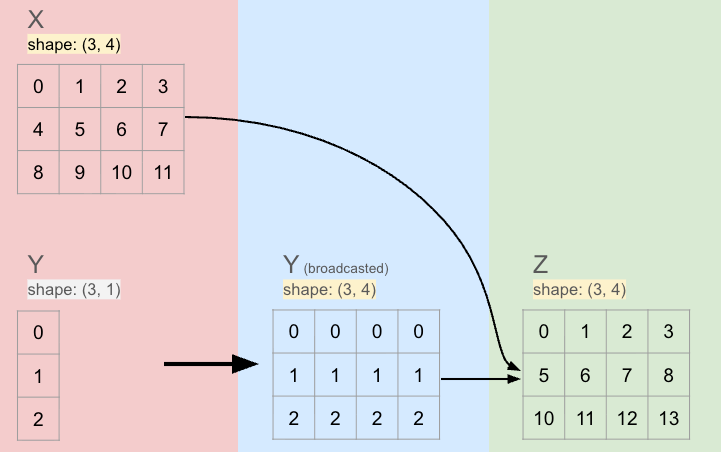
</details>

In [ ]:
X = np.arange(12).reshape(3, 4)
Y = np.arange(3).reshape(3, 1)
Z = X + Y
print(f"{X.shape=}\n{Y.shape=}\n{Z.shape=}")

X.shape=(3, 4)
Y.shape=(3, 1)
Z.shape=(3, 4)


In [ ]:
print(f"{X=}\n{Y=}\n{Z=}")

X=array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])
Y=array([[0],
       [1],
       [2]])
Z=array([[ 0,  1,  2,  3],
       [ 5,  6,  7,  8],
       [10, 11, 12, 13]])


**例子2：(N, M) + (1, M)**
<details>
<summary>查看解释</summary>

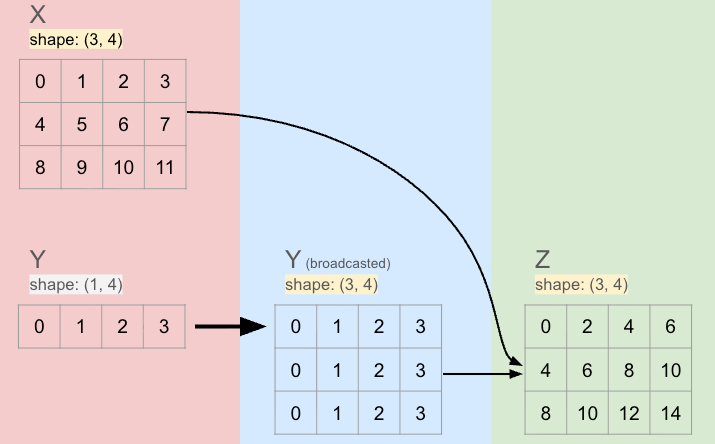
</details>


In [ ]:
X = np.arange(12).reshape(3, 4)
Y = np.arange(4).reshape(1, 4)
Z = X + Y
print(f"{X.shape=}\n{Y.shape=}\n{Z.shape=}")

X.shape=(3, 4)
Y.shape=(1, 4)
Z.shape=(3, 4)


In [ ]:
print(f"{X=}\n{Y=}\n{Z=}")

X=array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])
Y=array([[0, 1, 2, 3]])
Z=array([[ 0,  2,  4,  6],
       [ 4,  6,  8, 10],
       [ 8, 10, 12, 14]])


**例子3：(a, 1, c, d) + (a, b, c, 1)**
<details>
<summary>查看解释</summary>

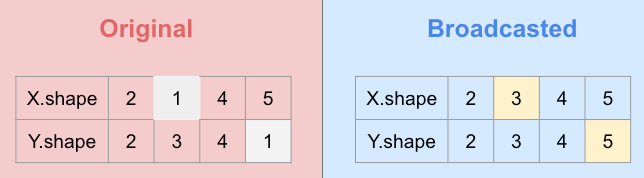

规则：对于每一维

*   长度相同的合法
*   长度不同，是1的变成对方
</details>

In [ ]:
X = np.zeros((2, 1, 4, 5))
Y = np.ones((2, 3, 4, 1))
Z = X + Y
print(f"{X.shape=}\n{Y.shape=}\n{Z.shape=}")

X.shape=(2, 1, 4, 5)
Y.shape=(2, 3, 4, 1)
Z.shape=(2, 3, 4, 5)


## 6.3 规则 (3)：dimension 不同，shape 右对齐并在前面补 1

### 6.3.1 不同维度参与广播

<details>
<summary>查看解释</summary>


规则：



*   维数不同，先右对齐
*   短的在前面补1
*   遵循上面的broadcast规则（规则2）。

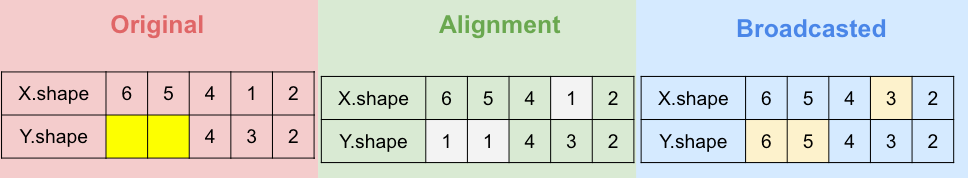




</details>

In [ ]:
X = np.zeros((6, 5, 4, 1, 2))
Y = np.ones((4, 3, 2))
Z = X + Y
print(f"{X.shape=}\n{Y.shape=      }\n{Z.shape=}")

X.shape=(6, 5, 4, 1, 2)
Y.shape=      (4, 3, 2)
Z.shape=(6, 5, 4, 3, 2)


### 6.3.2 特例：向量与 Tensor 运算（在最后一维广播）
<details>
<summary>查看解释</summary>

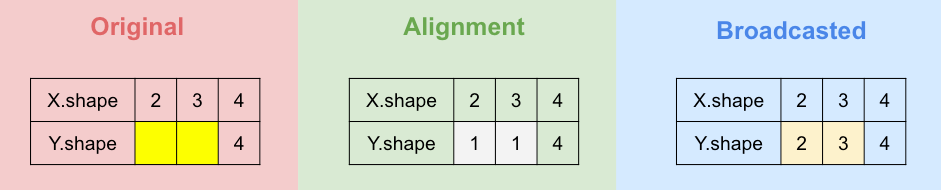
</details>

In [ ]:
X = np.zeros((2, 3, 4))
Y = np.arange(4)
Z = X + Y
print(f"{X.shape=}\n{Y.shape=}\n{Z.shape=}")

X.shape=(2, 3, 4)
Y.shape=(4,)
Z.shape=(2, 3, 4)


## 6.4 广播失败示例

- 如果两个数组对齐后，在任意一个维度上不匹配（既不相等、也不是1），那么整个 broadcasting 就会失败。

In [ ]:
X = np.zeros((5, 4, 1))
Y = np.zeros((4, 1, 3))
print(f"{X.shape=}\n{Y.shape=}")

X.shape=(5, 4, 1)
Y.shape=(4, 1, 3)


In [ ]:
try:
    X + Y
except ValueError as e:
    print('ValueError:', e)

ValueError: operands could not be broadcast together with shapes (5,4,1) (4,1,3) 


## 6.5 工程经验：手动对齐

In [ ]:
X = np.zeros((6, 5, 4, 1, 2))
Y = np.ones((4, 3, 2))

Y = Y.reshape(1, 1, 4, 3, 2)  # 手动对齐

Z = X + Y
print(f"{X.shape=}\n{Y.shape=}\n{Z.shape=}")

X.shape=(6, 5, 4, 1, 2)
Y.shape=(1, 1, 4, 3, 2)
Z.shape=(6, 5, 4, 3, 2)


---
# 第七章：矩阵乘法（@ / np.matmul）

## 7.1 二维矩阵：传统矩阵乘法

**矩阵乘法规则**

- $C = A \cdot B$
- $C[i, j] = A[i, :] \cdot B[:, j]$

**形状变化**

- $A: (m, n)$  
- $B: (n, p)$  
- $C: (m, p)$


In [ ]:
A = np.arange(6).reshape(2, 3)
B = np.arange(12).reshape(3, 4)
C = A @ B
print(f"{A.shape=}\n{B.shape=}\n{C.shape=}")

A.shape=(2, 3)
B.shape=(3, 4)
C.shape=(2, 4)


In [ ]:
print(f"{A=}\n{B=}\n{C=}")

A=array([[0, 1, 2],
       [3, 4, 5]])
B=array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])
C=array([[20, 23, 26, 29],
       [56, 68, 80, 92]])


## 7.2 高维矩阵：batch 维度广播 + 最后两维矩阵乘法

<details>
<summary>查看解释</summary>

**规则总结：**

- 最后两维做矩阵乘法：`(..., M, K) @ (..., K, N) -> (..., M, N)`
- 前面的维度视为 batch，遵守普通 broadcasting 规则

**例子：**
| | batch 维度（普通广播） | 矩阵维度（matmul 约束） |
|---|---|---|
| X | (6, 5, 4) | (3, 2) |
| Y | (5, 1) | (2, 7) |
| 右对齐后的 Y | (1, 5, 1) | (2, 7) |
| 输出 | (6, 5, 4) | (3, 7) |

</details>

In [ ]:
X = np.zeros((6, 5, 4, 3, 2))
Y = np.zeros((5, 1, 2, 7))
Z = X @ Y
print(f"{X.shape=}\n{Y.shape=   }\n{Z.shape=}")

X.shape=(6, 5, 4, 3, 2)
Y.shape=   (5, 1, 2, 7)
Z.shape=(6, 5, 4, 3, 7)


## 7.3 输入为向量 (不常用)

In [ ]:
# 1. 向量乘向量，结果为内积（点乘）
X = np.arange(3)                   # (3,)
Y = np.ones(3)                     # (3,)
Z = X @ Y                          # ()         # 标量, scalar

In [ ]:
# 2. 向量乘矩阵，向量视为行向量:
X = np.arange(3)                   # (3,)
Y = np.arange(12).reshape(3, 4)    # (3, 4)
Z = X @ Y                          # (4,)       # 输出是行向量，列的维度自动消掉

Y = np.arange(24).reshape(2, 3, 4) # (2, 3, 4)  # Y 是高维，前面为batch
Z = X @ Y                          # (2, 4)

In [ ]:
# 3. 矩阵乘向量，向量视为列向量:
X = np.arange(12).reshape(3, 4)   # (3, 4)
Y = np.arange(4)                  # (4)
Z = X @ Y                         # (3,)        # 输出是列向量，行的维度自动消掉

X = np.arange(24).reshape(2, 3, 4) # (2, 3, 4)  # X 是高维，前面为batch
Z = X @ Y                          # (2, 3)

## 7.4 API 说明：@ 与 np.matmul等价

In [ ]:
print(X @ Y)
print(np.matmul(X, Y))

[[ 14  38  62]
 [ 86 110 134]]
[[ 14  38  62]
 [ 86 110 134]]


---
# 第八章：Reduction 与 Axis

## 8.1 基本 reduction：sum 与 axis

<details>
<summary>查看解释</summary>

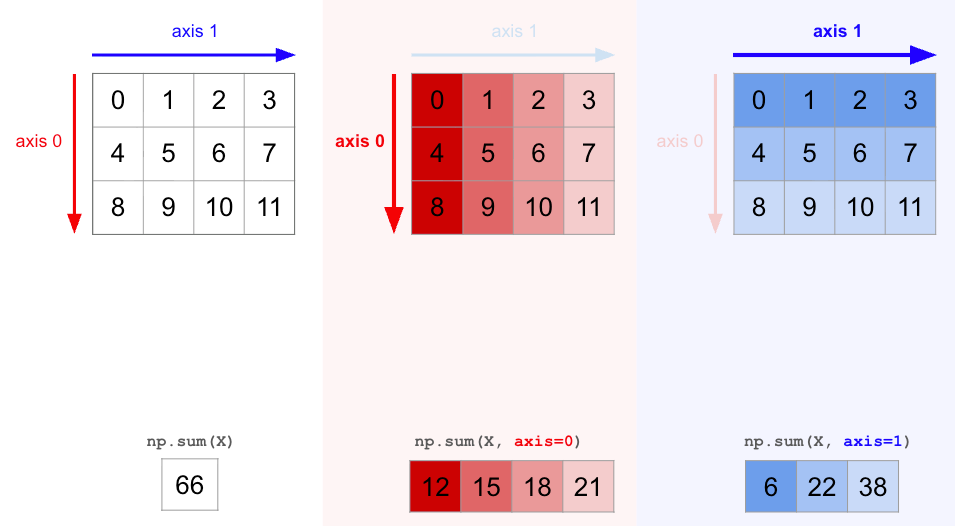
</details>

In [ ]:
X = np.arange(12).reshape(3, 4)
print(X)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [ ]:
np.sum(X)            # X 中所有元素加和

np.int64(66)

In [ ]:
np.sum(X, axis=0)    # 每列单独加和

array([12, 15, 18, 21])

In [ ]:
np.sum(X, axis=1)    # 每行单独加和

array([ 6, 22, 38])

## 8.2 keepdims：保留维度，便于后续广播

In [ ]:
X = np.random.rand(2, 3, 4, 5)
sum = np.sum(X, axis=(2,3), keepdims=True)
print(f"{X.shape=}\n{sum.shape=}")

X.shape=(2, 3, 4, 5)
sum.shape=(2, 3, 1, 1)


In [ ]:
X / sum

array([[[[0.05852752, 0.00513775, 0.04624563, 0.0618588 , 0.05143579],
         [0.04273207, 0.07750763, 0.02120115, 0.07779204, 0.06685808],
         [0.05144216, 0.02661038, 0.04506727, 0.08362819, 0.08785865],
         [0.05089255, 0.03433194, 0.01354339, 0.01897468, 0.07835434]],

        [[0.0272865 , 0.06777416, 0.08879355, 0.0617335 , 0.08944439],
         [0.05418029, 0.00704378, 0.00228311, 0.09013201, 0.05957689],
         [0.04838498, 0.06831585, 0.06870452, 0.01948179, 0.01301248],
         [0.05074703, 0.01250115, 0.08314248, 0.03107133, 0.05639022]],

        [[0.0174344 , 0.05353186, 0.05748035, 0.0440235 , 0.0494979 ],
         [0.05326313, 0.04491147, 0.05222054, 0.07224204, 0.04034324],
         [0.06223431, 0.04204325, 0.10151977, 0.07771601, 0.01573779],
         [0.0847307 , 0.02872557, 0.02867588, 0.03296758, 0.04070069]]],


       [[[0.08035955, 0.01182462, 0.08417454, 0.02517819, 0.06583356],
         [0.00014826, 0.07101726, 0.00162983, 0.07741717, 0.02895578]

## 8.3 常见 reduction：mean / std / max / argmax

In [ ]:
np.mean(X, axis=0)  # 每列求平均

array([[[0.70653337, 0.08467822, 0.65647736, 0.46294863, 0.59817917],
        [0.23790309, 0.76751907, 0.12542486, 0.79949325, 0.50864003],
        [0.57402424, 0.25176819, 0.38914305, 0.78201097, 0.64080385],
        [0.69735664, 0.49548282, 0.08162763, 0.52862985, 0.91155678]],

       [[0.51453715, 0.7321859 , 0.82946227, 0.80907987, 0.91049013],
        [0.47148035, 0.32671787, 0.40805947, 0.93377579, 0.57556998],
        [0.54736813, 0.79834918, 0.41558014, 0.55020817, 0.20433413],
        [0.72493022, 0.37466055, 0.89568464, 0.48186051, 0.30918979]],

       [[0.46829699, 0.65573245, 0.56179243, 0.53876029, 0.33751209],
        [0.53278261, 0.44701002, 0.59641514, 0.42224584, 0.62092386],
        [0.53968943, 0.49132769, 0.64997725, 0.43942948, 0.21016201],
        [0.42423533, 0.19981742, 0.27045547, 0.57897676, 0.55904673]]])

In [ ]:
np.std(X, axis=0)  # 每列的标准差

array([[[0.05677946, 0.02764056, 0.14307301, 0.22378811, 0.02715539],
        [0.23649482, 0.092946  , 0.10994359, 0.06412924, 0.2335972 ],
        [0.00292973, 0.04365181, 0.11117949, 0.14640268, 0.334575  ],
        [0.13236374, 0.11434049, 0.06872675, 0.31797898, 0.04169175]],

       [[0.23366211, 0.03454911, 0.08453873, 0.17362292, 0.01021032],
        [0.08622727, 0.25421231, 0.38455821, 0.00599728, 0.03768782],
        [0.04931487, 0.09513641, 0.29163338, 0.34967136, 0.07038944],
        [0.20256306, 0.24597934, 0.03985326, 0.16202619, 0.27126591]],

       [[0.30084415, 0.14157296, 0.00970869, 0.11592608, 0.1379023 ],
        [0.02120421, 0.01564707, 0.0948505 , 0.27162   , 0.23343763],
        [0.05805479, 0.08751328, 0.3250936 , 0.30701244, 0.05900462],
        [0.38958082, 0.07608419, 0.00496888, 0.26233177, 0.16812723]]])

In [ ]:
np.max(X, axis=1)  # 每行求最大值

array([[[0.64975391, 0.6976368 , 0.914001  , 0.68673673, 0.92070046],
        [0.55770761, 0.86046507, 0.50156464, 0.92777851, 0.74223723],
        [0.59774422, 0.70321277, 0.97507085, 0.92841365, 0.97537885],
        [0.81381615, 0.38114232, 0.85583138, 0.31983431, 0.86986503]],

       [[0.76914114, 0.79730541, 0.79955037, 0.98270279, 0.90027981],
        [0.55398682, 0.67457307, 0.79261768, 0.93977308, 0.85436149],
        [0.59668301, 0.89348558, 0.32488365, 0.89987953, 0.30622885],
        [0.92749328, 0.62063989, 0.9355379 , 0.84660883, 0.95324853]]])

In [ ]:
np.argmax(X, axis=1)  # 每行最大值的下标

array([[[0, 1, 1, 0, 1],
        [1, 0, 2, 1, 0],
        [2, 1, 2, 0, 0],
        [2, 0, 1, 1, 0]],

       [[2, 2, 0, 1, 1],
        [2, 0, 1, 1, 2],
        [1, 1, 2, 1, 0],
        [1, 1, 1, 0, 0]]])

## 8.4 高维 softmax 示例

**Softmax 函数**

Softmax 用于将一个向量映射为一个概率分布。

给定一个向量 $x = (x_1, x_2, \dots, x_n)$，softmax 定义为：

$$
\mathrm{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}
$$

**Softmax 的输出满足:**

- 每个元素都在 $(0, 1)$ 区间内
- 所有元素之和等于 1

In [ ]:
X = np.arange(2*3*4, dtype=np.float32).reshape(2, 3, 4) - 12
print(f"{X=}\n{X.shape=}")

X=array([[[-12., -11., -10.,  -9.],
        [ -8.,  -7.,  -6.,  -5.],
        [ -4.,  -3.,  -2.,  -1.]],

       [[  0.,   1.,   2.,   3.],
        [  4.,   5.,   6.,   7.],
        [  8.,   9.,  10.,  11.]]], dtype=float32)
X.shape=(2, 3, 4)


In [ ]:
def softmax(X):
    expX = np.exp(X)                                # shape: (2, 3, 4)
    expXSum = np.sum(expX, axis=-1, keepdims=True)  # shape: (2, 3, 1)
    return expX / expXSum                           # shape: (2, 3, 4)

softmaxX = softmax(X)
print(softmax(X))

[[[0.0320586  0.08714433 0.2368828  0.6439143 ]
  [0.0320586  0.08714432 0.23688282 0.6439142 ]
  [0.0320586  0.08714432 0.23688282 0.6439142 ]]

 [[0.0320586  0.08714432 0.2368828  0.6439143 ]
  [0.0320586  0.08714432 0.2368828  0.6439143 ]
  [0.0320586  0.08714432 0.23688284 0.6439143 ]]]


In [ ]:
# 验证：softmax最后一维求和应为全 1（形状: 2 x 3）
np.sum(softmaxX, axis=-1)

array([[1., 1., 1.],
       [1., 1., 1.]], dtype=float32)

## 8.5 工程经验:
- 尽量避免 Python 层面的循环。
- 尽量使用 Numpy 中的批处理、向量化操作。
- 一般情况下，数值计算性能会大幅提升。

In [ ]:
# 手动循环版softmax
def softmax_using_loop(X):
    output = np.zeros_like(X, dtype=np.float32)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            x_slice = X[i, j, :]
            exp_x_slice = np.array([np.exp(val) for val in x_slice])
            sum_exp_x_slice = np.sum(exp_x_slice)
            softmax_slice = exp_x_slice / sum_exp_x_slice
            output[i, j, :] = softmax_slice
    return output

In [ ]:
X_large = np.random.rand(100, 100, 100).astype(np.float32)

# 批处理版softmax性能测试:
%timeit softmax(X_large)
# 循环版softmax性能测试：
%timeit softmax_using_loop(X_large)

10.4 ms ± 3.91 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.53 s ± 1.1 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


# tile flipping

array([[[ 49,  49,  49],
        [ 23,  23,  23],
        [ 23,  23,  23],
        ...,
        [ 23,  23,  23],
        [ 23,  23,  23],
        [104, 104, 104]],

       [[ 22,  22,  22],
        [152, 152, 152],
        [197, 197, 197],
        ...,
        [197, 197, 197],
        [197, 197, 197],
        [224, 224, 224]],

       [[ 23,  23,  23],
        [197, 197, 197],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[ 23,  23,  23],
        [197, 197, 197],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[ 23,  23,  23],
        [197, 197, 197],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[104, 104, 104],
        [224, 224, 224],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
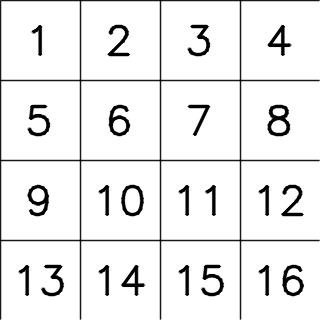

array([[[  2,   2,   2],
        [ 18,  18,  18],
        [ 23,  23,  23],
        ...,
        [ 23,  23,  23],
        [ 23,  23,  23],
        [ 18,  18,  18]],

       [[ 18,  18,  18],
        [152, 152, 152],
        [197, 197, 197],
        ...,
        [197, 197, 197],
        [197, 197, 197],
        [156, 156, 156]],

       [[ 23,  23,  23],
        [197, 197, 197],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [202, 202, 202]],

       ...,

       [[ 23,  23,  23],
        [197, 197, 197],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [202, 202, 202]],

       [[ 23,  23,  23],
        [197, 197, 197],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [202, 202, 202]],

       [[ 18,  18,  18],
        [156, 156, 156],
        [202, 202, 202],
        ...,
        [202, 202, 202],
        [202, 202, 202],
        [160, 160, 160]]], dtype=uint8)
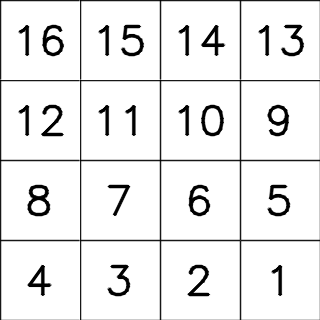

In [ ]:
import numpy as np
import cv2

def make_4x4_tile_image_cv2(tile_size=80, margin=6, thickness=2):
    """
    生成严格形状为 (4*tile_size, 4*tile_size) 的 BGR 图像：
    - 4x4 tile
    - 每个 tile 中央写数字 1~16（精确像素控制）
    """
    H = W = 4 * tile_size
    img = np.full((H, W, 3), 255, dtype=np.uint8)  # 白底

    # 可选：画网格线，帮助观感（不影响 reshape/slicing，只要 tile_size 对齐）
    for k in range(5):
        y = k * tile_size
        x = k * tile_size
        cv2.line(img, (0, y), (W - 1, y), (0, 0, 0), 1, cv2.LINE_AA)
        cv2.line(img, (x, 0), (x, H - 1), (0, 0, 0), 1, cv2.LINE_AA)

    font = cv2.FONT_HERSHEY_SIMPLEX

    n = 1
    for i in range(4):
        for j in range(4):
            text = str(n)

            # 动态选择字号：确保数字能放进 tile（简单按 tile_size 比例缩放）
            # 你也可以固定 font_scale，比如 1.0
            font_scale = tile_size / 60.0

            (tw, th), baseline = cv2.getTextSize(text, font, font_scale, thickness)

            # tile 的像素范围
            y0 = i * tile_size
            x0 = j * tile_size

            # 计算“居中放置”的文字左下角 (x, y)
            # putText 的坐标是文字 baseline 的左下角
            cx = x0 + tile_size // 2
            cy = y0 + tile_size // 2

            x = int(cx - tw / 2)
            y = int(cy + th / 2)

            # 可选：确保不贴边
            x = max(x0 + margin, min(x, x0 + tile_size - margin - tw))
            y = max(y0 + margin + th, min(y, y0 + tile_size - margin))

            cv2.putText(img, text, (x, y), font, font_scale, (0, 0, 0),
                        thickness, cv2.LINE_AA)

            n += 1

    return img

def flip_tiles_bgr(img_bgr, tile_size):
    """
    tile 级别上下+左右翻转（只翻 tile，不翻 tile 内部），BGR 版本
    只用 reshape + slicing
    """
    if img_bgr.ndim != 3 or img_bgr.shape[2] != 3:
        raise ValueError(f"Expect BGR image (H,W,3), got {img_bgr.shape}")
    H, W, C = img_bgr.shape
    if H % tile_size != 0 or W % tile_size != 0:
        raise ValueError(f"H,W must be divisible by tile_size. Got {img_bgr.shape}, tile_size={tile_size}")

    ht = H // tile_size
    wt = W // tile_size

    blocks = img_bgr.reshape(ht, tile_size, wt, tile_size, C)
    blocks_flipped = blocks[::-1, :, ::-1, :, :]
    return blocks_flipped.reshape(H, W, C)



tile_size = 80
img = make_4x4_tile_image_cv2(tile_size=tile_size)
img_flip = flip_tiles_bgr(img, tile_size=tile_size)
display(img)
display(img_flip)

# if __name__ == "__main__":
#     tile_size = 80
#     img = make_4x4_tile_image_cv2(tile_size=tile_size)
#     img_flip = flip_tiles_bgr(img, tile_size=tile_size)

#     # 用 OpenCV 预览（或你也可以用 matplotlib imshow）
#     cv2.imshow("original", img)
#     cv2.imshow("tile_flip", img_flip)
#     cv2.waitKey(0)
#     cv2.destroyAllWindows()
